<a href="https://colab.research.google.com/github/ikehone1/Vehicle-Dynamics-Simulator/blob/main/Full_Vehicle_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Variables
import numpy as np
# MASSES
m_s = 1600 #kg  # Vehicle Cab Mass
m_uf = 40 #kg   tire+rim+brakes
m_ur = 40 #kg   tire+rim+brakes
# CONSTANTS
# RIGHT SIDE
k_sf1 = 60000 # N/m   Front Wheel          #60000 to 150000+ for race cars
c_sf1 = 10000 # Ns/m   Front Wheel
k_sr1 = 60000 # N/m   Rear Wheel
c_sr1 = 10000 # Ns/m   Rear Wheel
k_tf1 = 200000 # N/m   tire stiffness
k_tr1 = 200000 # N/m
# LEFT SIDE
k_sf2 = 60000 # N/m   Front Wheel          #60000 to 150000+ for race cars
c_sf2 = 10000 # Ns/m   Front Wheel
k_sr2 = 60000 # N/m   Rear Wheel
c_sr2 = 10000 # Ns/m   Rear Wheel
k_tf2 = 200000 # N/m   tire stiffness
k_tr2 = 200000 # N/m

# POSITION AND VELOCITY VARIABLES
z_s = 0.0  #Car center of mass position/displacement
# RIGHT SIDE
z_uf_RT = 0.0      #Front tire position/displacement
z_ur_RT = 0.0      #Rear tire position
z1_s = 0.0      #Car center of mass velocity
z1_uf_RT = 0.0     #Front tire velocity
z1_ur_RT = 0.0     #Rear tire velocity
#LEFT SIDE
z_uf_LT = 0.0      #Front tire position/displacement
z_ur_LT = 0.0      #Rear tire position
z1_s_LT = 0.0      #Car center of mass velocity
z1_uf_LT = 0.0     #Front tire velocity
z1_ur_LT = 0.0     #Rear tire velocity


t = 0.0 # seconds
# WHEELBASE DIMENSIONS
a = 1.2 # meters  distance from CG to front axle
b = 1.8 # meters  distance from CG to rear axle
c = 0.9 # meters  distance from CG to RIGHT wheels
d = 0.9 # meters  distance from CG to LEFT wheels
h = 0.16 # meters        Ride Height
r_tire = 0.2286 #meters  Tire Radius

# PITCH AND ROLL VARIABLES
theta = 0.0 #radians     Car Pitch
theta1 = 0.0
ro = 0.0  #radians       Car Roll
ro1 = 0.0

g = 9.81 # m/s^2
z_r = 0.0
vel = 20 #m/s
delay = (a+b)/vel

# SUSPENSION BOUNDS
max_travel = 0.1524      #MAX suspension travel
min_travel = 0.0508      #MIN suspension travel
k_b = 100000 #N/m       #Suspension Bumper "spring constant"

In [ ]:
#Plotting Functions
def simple_plot(x_value, y_value, xlabel, ylabel, title):
  import matplotlib.pyplot as plt
  plt.figure()
  plt.plot(x_value, y_value)
  plt.xlabel(f'{xlabel}')
  plt.ylabel(f'{ylabel}')
  plt.title(f'{title}' )
  plt.grid
  plt.show()


def plot_overlay(x_value, y1_value, y2_value, xlabel, ylabel, title, line1, line2):
  import matplotlib.pyplot as plt
  plt.figure()
  plt.plot(x_value, y1_value, label=line1)
  plt.plot(x_value, y2_value, label=line2, linestyle='--')
  plt.xlabel(f'{xlabel}')
  plt.ylabel(f'{ylabel}')
  plt.title(f'{title}')
  plt.grid()
  plt.legend()
  plt.show()

def tripleplot_overlay(x_value, y1_value, y2_value, y3_value, xlabel, ylabel, title, line1, line2, line3):
  import matplotlib.pyplot as plt
  plt.figure()
  plt.plot(x_value, y1_value, label=line1)
  plt.plot(x_value, y2_value, label=line2, linestyle='--')
  plt.plot(x_value, y3_value, label=line3, linestyle='-.')
  plt.xlabel(f'{xlabel}')
  plt.ylabel(f'{ylabel}')
  plt.title(f'{title}')
  plt.grid()
  plt.legend()
  plt.show()

In [ ]:
#Random Road input
import random
def rand_roadinput(t):
  if t < 1.000 or t > 1.100 and t < 2.000 or t > 2.100:
    #z_r = 0.0
    z_r = random.uniform(-0.005, 0.005)
  if t >= 1.000 and t <= 1.100:
    z_r = random.uniform(0.00, 0.11)
  if t >= 2.000 and t <= 2.100:
    z_r = random.uniform(-0.01, 0.00)
  return z_r

In [ ]:
A = [z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, delay, t]
#Car acceleration  a = F/m
def FullCar_Accel(*A):
  #Road Input
  z_rf = rand_roadinput(t)
  z_rr = rand_roadinput(t-delay)
  #Deflections
  dsf_RT = (z_s + ((a*theta) + (c*ro))) - z_uf_RT    # a*theta is arc length
  dsr_RT = (z_s - ((b*theta) + (c*ro))) - z_ur_RT
  dsf_LT = (z_s + ((a*theta) + (d*ro))) - z_uf_LT
  dsr_LT = (z_s - ((b*theta) + (d*ro))) - z_uf_LT

  #Deflection Velocity
  d1sf_RT = (z1_s + a*theta1) - z1_uf_RT
  d1sr_RT = (z1_s - b*theta1) - z1_ur_RT
  d1sf_LT = (z1_s + a*theta1) - z1_uf_LT
  d1sr_LT = (z1_s - b*theta1) - z1_ur_LT

  #Forces
  F_sf_RT = (k_sf1*dsf_RT) + (c_sf1*d1sf_RT)
  F_sr_RT = (k_sr1*dsr_RT) + (c_sr1*d1sr_RT)
  F_sf_LT = (k_sf2*dsf_LT) + (c_sf2*d1sf_RT)
  F_sr_LT = (k_sr2*dsr_LT) + (c_sr2*d1sr_RT)

  #Moments
  Ma = (F_sf_RT + F_sf_LT) * a
  Mb = (F_sr_RT + F_sr_LT) * b
  Mc = (F_sf_RT + F_sr_RT) * c            # RIGHT Moment
  Md = (F_sf_RT + F_sr_LT) * d            # LEFT Moment

  #if min_travel > dsf_RT > max_travel:                #Bounding the suspension
    #F_sf_RT += k_b*(dsf_RT - max_travel)
  #if min_travel > dsr_RT > max_travel:
    #F_sr_RT += k_b*(dsr_RT - max_travel)
  #if min_travel > dsf_LT > max_travel:                #Bounding the suspension
    #F_sf_LT += k_b*(dsf_LT - max_travel)
  #if min_travel > dsr_RT > max_travel:
    #F_sr_LT += k_b*(dsr_LT - max_travel)

  #Inertia
  Iyy = m_s*((a+b)**2)*0.2  #0.2 is scaling factor
  Ixx = m_s*((c+d)**2)*0.2

  #Accelerations
  a_s_RT = ((-k_sf1*(z_s - z_uf_RT))-(k_sr1*(z_s - z_ur_RT))-(c_sf1*(z1_s - z1_uf_RT))-(c_sr1*(z1_s - z1_ur_RT))) / m_s
  a_s_LT = ((-k_sf2*(z_s - z_uf_LT))-(k_sr2*(z_s - z_ur_LT))-(c_sf2*(z1_s - z1_uf_LT))-(c_sr2*(z1_s - z1_ur_LT))) / m_s
  a_s_total = a_s_RT + a_s_LT
  a_uf_RT = ((k_sf1*(z_s - z_uf_RT)) + (c_sf1*(z1_s - z1_uf_RT)) - (k_tf1*(z_uf_RT - z_rf))) / m_uf
  a_ur_RT = ((k_sr1*(z_s - z_ur_RT)) + (c_sr1*(z1_s - z1_ur_RT)) - (k_tr1*(z_ur_RT - z_rr))) / m_ur
  a_uf_LT = ((k_sf2*(z_s - z_uf_LT)) + (c_sf2*(z1_s - z1_uf_LT)) - (k_tf2*(z_uf_LT - z_rf))) / m_uf
  a_ur_LT = ((k_sr2*(z_s - z_ur_LT)) + (c_sr2*(z1_s - z1_ur_LT)) - (k_tr2*(z_ur_LT - z_rr))) / m_ur
  a_theta = (-Ma + Mb) / Iyy  #mass cancels out
  a_ro = (-Mc + Md) / Ixx
  return a_s_total, a_uf_RT, a_ur_RT, a_uf_LT, a_ur_LT, a_theta, a_ro, z_rf, z_rr, a_s_RT, a_s_LT, dsf_RT, Ma, Ixx, Iyy

a_s_total, a_uf_RT, a_ur_RT, a_uf_LT, a_ur_LT, a_theta, a_ro, z_rf, z_rr, a_s_RT, a_s_LT, dsf_RT, Ma, Ixx, Iyy = FullCar_Accel(*A)
Y = [a_s_total, a_uf_RT, a_ur_RT, a_uf_LT, a_ur_LT, a_theta, a_ro, z_rf, z_rr, a_s_RT, a_s_LT]

In [ ]:
B = [z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, t]
C = [z1_s, a_s_total, z1_uf_RT, a_uf_RT, z1_ur_RT, a_ur_RT, z1_uf_LT, a_uf_LT, z1_ur_LT, a_ur_LT, theta1, a_theta, ro1, a_ro]
Y = [a_s_total, a_uf_RT, a_ur_RT, a_uf_LT, a_ur_LT, a_theta, a_ro, z_rf, z_rr, a_s_RT, a_s_LT, dsf_RT]
#RK4 Step
def RK4_step(z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, t):

  def Q(z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, t):
    a_s_total, a_uf_RT, a_ur_RT, a_uf_LT, a_ur_LT, a_theta, a_ro, z_rf, z_rr, a_s_RT, a_s_LT, dsf_RT, Ma, Ixx, Iyy = FullCar_Accel(z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT, theta, theta1, ro, ro1, delay, t)
    return np.array([z1_s, a_s_total, z1_uf_RT, a_uf_RT, z1_ur_RT, a_ur_RT, z1_uf_LT, a_uf_LT, z1_ur_LT, a_ur_LT, theta1, a_theta, ro1, a_ro])

  X = np.array([z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1])

  k1 = Q(*X, t)
  k2 = Q(*(X + (0.5*k1*dt)), (t + 0.5*dt))
  k3 = Q(*(X + (0.5*k2*dt)), (t + 0.5*dt))
  k4 = Q(*(X + (k3*dt)), (t + dt))

  X_next = X + ((k1 + 2*k2 + 2*k3 + k4)/6) * dt
  return X_next

In [ ]:
#RK4 Solver
t = 0.0
t_end_rk4 = 3.0 #sec
dt = 0.0001

Time = []
Zs = []
Zuf_RT = []
Zur_RT = []
Zuf_LT = []
Zur_LT = []
Z1s = []
Z1uf_RT = []
Z1ur_RT = []
Z1uf_LT = []
Z1ur_LT = []
Pitch = []
Pitch_Vel = []
Roll = []
Roll_Vel = []
Zrf = []
Zrr = []
AsRT = []
AsLT = []
DSFRT = []
MOMA = []
IXX = []
IYY = []

while t < t_end_rk4:
  #A = [z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, delay, t]
  #B = [z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, t]
  #C = [z1_s, a_s_total, z1_uf_RT, a_uf_RT, z1_ur_RT, a_ur_RT, z1_uf_RT, a_uf_RT, z1_ur_RT, a_ur_RT, theta1, a_theta, ro1, a_ro]
  #Y = [a_s_RT, a_s_LT, a_s_total, a_uf_RT, a_ur_RT, a_uf_LT, a_ur_LT, a_theta, a_ro, z_rf, z_rr]
  #X = np.array([z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1])

  a_s_total, a_uf_RT, a_ur_RT, a_uf_LT, a_ur_LT, a_theta, a_ro, z_rf, z_rr, a_s_RT, a_s_LT, dsf_RT, Ma, Ixx, Iyy  = FullCar_Accel(z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, delay, t)
  z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1 = RK4_step(z_s, z1_s, z_uf_RT, z1_uf_RT, z_ur_RT, z1_ur_RT, z_uf_LT, z1_uf_LT, z_ur_LT, z1_ur_LT,  theta, theta1, ro, ro1, t)
  #ENG = (0.5*m_s*z1_s**2)+(0.5*k_sf*(z))
  t += dt

  Time.append(t)
  Zs.append(z_s)
  Zuf_RT.append(z_uf_RT)
  Zur_RT.append(z_ur_RT)
  Zuf_LT.append(z_uf_LT)
  Zur_LT.append(z_ur_LT)
  Z1s.append(z1_s)
  Z1uf_RT.append(z1_uf_RT)
  Z1ur_RT.append(z1_ur_RT)
  Z1uf_LT.append(z1_uf_LT)
  Z1ur_LT.append(z1_ur_LT)
  Pitch.append(theta)
  Pitch_Vel.append(theta1)
  Roll.append(ro)
  Roll_Vel.append(ro1)
  Zrf.append(z_rf)
  Zrr.append(z_rr)
  AsRT.append(a_s_RT)
  AsLT.append(a_s_LT)
  DSFRT.append(dsf_RT)
  MOMA.append(Ma)
  IXX.append(Ixx)
  IYY.append(Iyy)

In [ ]:
print(MOMA)
print(Iyy)
print(Ixx)
print(DSFRT)

[np.float64(-4.4073620863982206e+80), np.float64(-4.3832947421293663e+80), np.float64(-4.359246388029359e+80), np.float64(-4.33521708091242e+80), np.float64(-4.31120687743285e+80), np.float64(-4.287215834085119e+80), np.float64(-4.263244007203915e+80), np.float64(-4.2392914529641947e+80), np.float64(-4.215358227381271e+80), np.float64(-4.191444386310839e+80), np.float64(-4.167549985449074e+80), np.float64(-4.143675080332663e+80), np.float64(-4.119819726338892e+80), np.float64(-4.0959839786856917e+80), np.float64(-4.072167892431714e+80), np.float64(-4.0483715224763864e+80), np.float64(-4.0245949235599875e+80), np.float64(-4.000838150263694e+80), np.float64(-3.977101257009675e+80), np.float64(-3.953384298061125e+80), np.float64(-3.929687327522363e+80), np.float64(-3.9060103993388663e+80), np.float64(-3.882353567297364e+80), np.float64(-3.858716885025901e+80), np.float64(-3.8351004059938915e+80), np.float64(-3.8115041835122023e+80), np.float64(-3.7879282707332174e+80), np.float64(-3.76437

In [ ]:
import csv
filename = f"HalfCar_Data1.csv"
with open(filename, "w", newline="") as f:
    writer = csv.writer(f)

     #Header
    writer.writerow([
        "Time_s",
        "SprungMassPos_m",
        "F_WheelPos_m",
        "R_WheelPos_m",
        "SprungVel",
        "F_WheelVel",
        "R_WheelVel",
        "Pitch",
        "PitchVel",
        "RoadInputFront_m",
        "RoadInputRear_m"
      ])

    #Time History
    for t, Z_s, Z_uf, Z_ur, Z1_s, Z1_uf, Z1_ur, Theta, ThetaVel, Z_rf, Z_rr in zip(Time, Zs, Zuf, Zur, Z1s, Z1uf, Z1ur, Pitch, Pitch_Vel, Zrf, Zrr):
       writer.writerow([t, Z_s, Z_uf, Z_ur, Z1_s, Z1_uf, Z1_ur, Theta, ThetaVel, Z_rf, Z_rr])

print(f'Saved {filename}')

NameError: name 'Zuf' is not defined

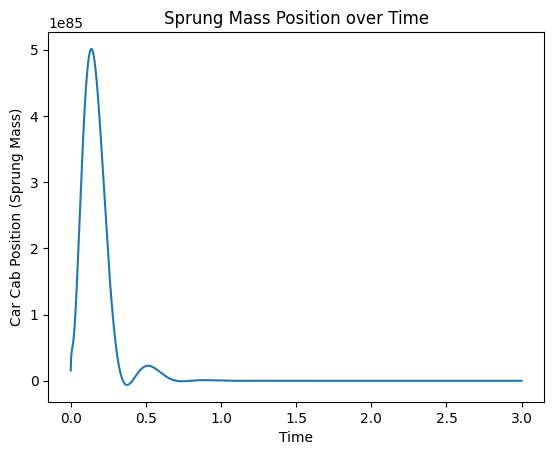

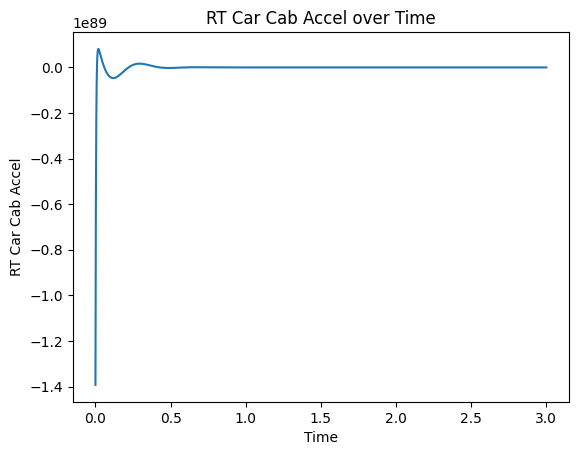

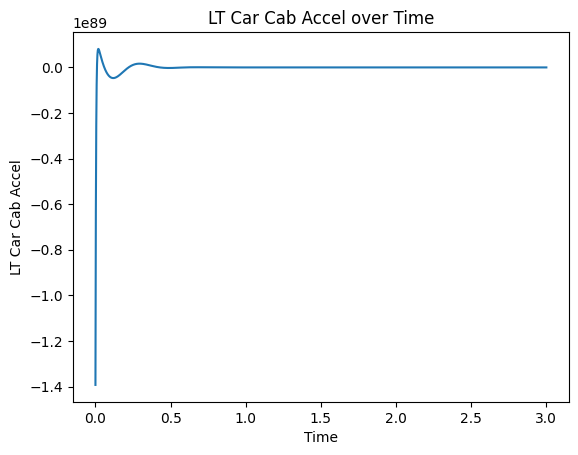

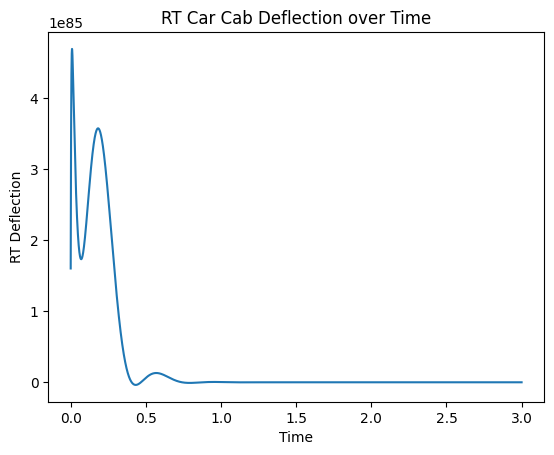

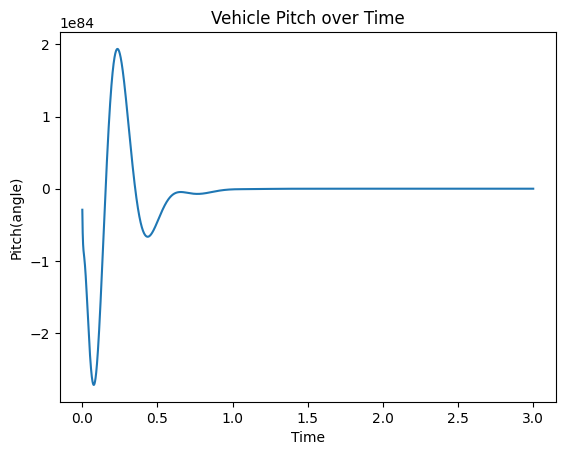

KeyboardInterrupt: 

In [ ]:
simple_plot(Time, Zs, 'Time', 'Car Cab Position (Sprung Mass)', 'Sprung Mass Position over Time')
simple_plot(Time, AsRT, 'Time', 'RT Car Cab Accel', 'RT Car Cab Accel over Time')
simple_plot(Time, AsLT, 'Time', 'LT Car Cab Accel', 'LT Car Cab Accel over Time')
simple_plot(Time, DSFRT, 'Time', 'RT Deflection', 'RT Car Cab Deflection over Time')
#tripleplot_overlay(Time, Zs, Zrf, Zrr, 'Time', 'Car Cab Position with Road Input', 'Cab Position with Road Input over Time', 'Cab', 'Front Road Input', 'Rear Road Input')
#simple_plot(Time, Zuf, 'Time', 'Front Wheel Position', 'Front Wheel Position over Time')
#simple_plot(Time, Zur, 'Time', 'Rear Wheel Position', 'Rear Wheel Position over Time')
#plot_overlay(Time, Zuf, Zrf, 'Time', 'Front Wheel Position (m)', 'Front Wheel Position with Road Input', 'Front Wheel', 'Road Input')
#simple_plot(Time, Z1s, 'Time', 'Car Cab Velocity ', 'Sprung Mass Velocity over Time')
simple_plot(Time, Pitch, 'Time', 'Pitch(angle)', 'Vehicle Pitch over Time')
simple_plot(Time, Roll, 'Time', 'Roll(angle)', 'Vehicle Roll over Time')
#plot_overlay(Time, Zuf, Zur, 'Time', 'Wheel Position (m)', 'Wheel Position', 'Front Wheel', 'Rear Wheel')